# Project: Mixed Quantum State Preparation

## 1. Introduction

In quantum mechanics, a mixed state is mathematically represented by a density matrix $\rho$. While quantum algorithms frequently assume an idealized environment, real-world systems are rarely perfectly isolated. Because quantum circuits operate via unitary transformations, they inherently evolve closed systems deterministically and thus naturally output pure states. 

The objective of this project is to bridge that gap by developing a generalized Qiskit function that takes an arbitrary $2^n \times 2^n$ density matrix $\rho \in \mathbb{C}^{2^n \times 2^n}$ and outputs a circuit $U$ (with measurements) that prepares this exact state. We achieve this using the method of state purification, employing any number of ancillas, arbitrary 1-qubit gates, and multiplexed Z-rotations.

## 2. Theoretical Background

### 2.1 Density Matrices and Statistical Ensembles
In standard quantum mechanics, a perfectly isolated system is described by a pure state vector $|\psi\rangle$. However, real physical systems frequently interact with their environments or are prepared using processes that introduce classical uncertainty. To capture this statistical mixture of pure states, we must use the density matrix formalism.

If a quantum system is prepared in a state $|\psi_i\rangle$ with a classical probability $p_i$, its density matrix $\rho$ is defined as:
$$
\rho = \sum_{i} p_i |\psi_i\rangle \langle \psi_i|
$$
where $p_i \geq 0$ and $\sum_i p_i = 1$. It is crucial to note that the component states $\{|\psi_i\rangle\}$ do not necessarily form an orthogonal basis.

For an $n$-qubit system, $\rho$ is a $2^n \times 2^n$ complex matrix. To represent a valid physical ensemble, $\rho$ must satisfy three foundational properties:
1. **Hermitian ($\rho = \rho^\dagger$):** This guarantees that the expectation values of physical observables are strictly real numbers. For any observable $A$, its expectation value is calculated as $\langle A \rangle = \text{Tr}(\rho A)$.
2. **Positive Semi-Definite ($\langle \phi | \rho | \phi \rangle \geq 0$):** This ensures that the physical probability of measuring the system in any given state is always non-negative.
3. **Unit Trace ($\text{Tr}(\rho) = 1$):** This represents the conservation of probability. The sum of the probabilities of all mutually exclusive measurement outcomes must equal exactly 1.

Furthermore, the density matrix provides a straightforward mathematical test to determine if a system is pure or mixed by calculating its purity, defined as $\text{Tr}(\rho^2)$. For a completely pure state, $\text{Tr}(\rho^2) = 1$. For a genuinely mixed state, $\text{Tr}(\rho^2) < 1.$

### 2.2 Spectral Decomposition and Ensemble Ambiguity
Because the density matrix $\rho$ is both Hermitian and positive semi-definite, the spectral theorem guarantees that it can be exactly diagonalized. The spectral decomposition of $\rho$ is expressed as:
$$
\rho = \sum_{i=0}^{2^n-1} p_i |\psi_i\rangle \langle \psi_i|
$$
where $p_i$ are the non-negative real eigenvalues ($\sum_i p_i = 1$) and $|\psi_i\rangle$ are the corresponding orthonormal eigenvectors.

From a physical standpoint, this decomposition addresses the phenomenon of ensemble ambiguity. A quantum system might be initially prepared by mixing non-orthogonal states, which cannot be perfectly distinguished by any measurement. However, the spectral decomposition demonstrates that any density matrix can be equivalently interpreted as a statistical mixture of perfectly distinguishable, orthogonal pure states. The quantum state preparation algorithm strictly relies on this orthogonal basis to map probability amplitudes.

### 2.3 State Purification and the Partial Trace
Quantum computing frameworks rely on closed-system dynamics. Because quantum circuits operate via unitary transformations ($U U^\dagger = I$), they evolve systems deterministically. Consequently, a quantum circuit initialized in a pure state will strictly output another pure state. We cannot natively generate a mixed state $\rho$ using solely unitary gates acting on the target system.

To circumvent this limitation, we utilize a mathematical technique formally known as state purification. According to the purification theorem, any mixed state $\rho_S$ acting on a primary system $S$ can be viewed as the reduced density matrix of a pure state $|\Psi\rangle$ on a composite system $S \otimes A$, where $A$ is an auxiliary reference, or ancilla system.

Given the spectral decomposition $\rho_S = \sum_{i} p_i |\psi_i\rangle_S \langle \psi_i|_S$, we construct the purified entangled state as:
$$
|\Psi\rangle_{SA} = \sum_{i} \sqrt{p_i} |\psi_i\rangle_S \otimes |i\rangle_A
$$
where $|i\rangle_A$ forms an arbitrary orthonormal computational basis for the ancilla register.

To recover the target mixed state for our main system $S$, we apply the partial trace over the ancilla system $A$:
$$
\text{Tr}_A(|\Psi\rangle_{SA} \langle\Psi|_{SA}) = \sum_{i} p_i |\psi_i\rangle_S \langle \psi_i|_S = \rho_S
$$
Physically, taking the partial trace corresponds to deliberately ignoring the ancilla subsystem. In the context of our quantum circuit, we measure the ancilla register and discard the classical readout. This intentional loss of information effectively collapses the system $S$ into the exact statistical mixture described by $\rho_S.$

### 2.4 Circuit Implementation Strategy
Preparing this purified state within a quantum circuit requires a sequential, two-step unitary operation followed by a non-unitary measurement step. We break this down as follows:

**1. Preparing the Ancilla Eigenvalue Distribution**
We begin by initializing a register of $n$ ancilla qubits in the ground state $|0\rangle^{\otimes n}_A$. We then apply a unitary state preparation operator, $U_{\text{anc}}$, designed to create a superposition where the probability amplitudes correspond exactly to the square roots of our target eigenvalues:
$$
U_{\text{anc}} |0\rangle^{\otimes n}_A = \sum_{i=0}^{2^n-1} \sqrt{p_i} |i\rangle_A
$$
This involves synthesizing a state preparation circuit utilizing arbitrary 1-qubit gates and multiplexed Z-rotations to systematically divide the probability amplitudes across the computational basis states of the ancilla register.

**2. Entangling the System Qubits via Multiplexed Operations**
Next, we initialize the main system register with $n$ qubits in the state $|0\rangle^{\otimes n}_S$. To construct the required purified state, we must map the system register to the specific eigenvector $|\psi_i\rangle_S$ strictly conditioned on the ancilla register being in the corresponding state $|i\rangle_A$.

We achieve this by applying a highly controlled unitary block, $U_{\text{ent}}$. Mathematically, this block is a sum of conditionally applied unitaries $V_i$, where each $V_i$ is defined by $V_i|0\rangle^{\otimes n}_S = |\psi_i\rangle_S$:
$$
U_{\text{ent}} = \sum_{i=0}^{2^n-1} |i\rangle \langle i|_A \otimes V_i
$$
Applying $U_{\text{ent}}$ to the combined system yields the fully entangled state:
$$
U_{\text{ent}} \left( \sum_{i=0}^{2^n-1} \sqrt{p_i} |i\rangle_A \otimes |0\rangle^{\otimes n}_S \right) = \sum_{i=0}^{2^n-1} \sqrt{p_i} |i\rangle_A \otimes |\psi_i\rangle_S
$$
In practice, $U_{\text{ent}}$ is synthesized as a multiplexed state preparation block. We iterate through each non-zero eigenvalue, applying Pauli-X gates to the ancilla to explicitly isolate the control state $|i\rangle_A$, executing the controlled state preparation on the system, and then uncomputing the X gates to restore the ancilla.

**3. The Partial Trace via Measurement**
After the unitary steps are executed, measuring the $n$ ancilla qubits into a classical register and intentionally discarding the classical readout traces out the ancilla degrees of freedom. The system register $S$ is left in a statistical mixture of the pure states $|\psi_i\rangle_S$ weighted precisely by the classical probabilities $p_i$, thereby outputting the exact target density matrix $\rho$.

## 3. Qiskit Implementation

With the textbook theoretical framework established, we encapsulate the logic into a reusable Qiskit function `prepare_mixed_state(rho)`. This function handles the classical spectral decomposition, automatically generates the necessary unitary blocks, and applies the final measurements to trace out the ancilla.

First, we import the necessary libraries from Qiskit and NumPy.

In [1]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import StatePreparation

### 3.1 Defining the Core Function

Here we define the `prepare_mixed_state` generalized function.

In [2]:
def prepare_mixed_state(rho: np.ndarray) -> QuantumCircuit:
    """
    Generates a quantum circuit that prepares a given mixed state via purification.
    
    Parameters:
    rho (np.ndarray): A 2^n x 2^n positive semi-definite Hermitian matrix with unit trace.
    
    Returns:
    QuantumCircuit: The compiled Qiskit circuit with measurements applied to the ancilla.
    """
    # Determine the system size dynamically from the input matrix
    dim = rho.shape[0]
    n = int(np.log2(dim))
    
    # 1. Classical Spectral Decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(rho)
    
    # Enforce physical constraints to handle floating-point inaccuracies
    eigenvalues[eigenvalues < 0] = 0
    eigenvalues = eigenvalues / np.sum(eigenvalues)
    
    # Calculate probability amplitudes for the ancilla register
    amplitudes = np.sqrt(eigenvalues)
    
    # Initialize the quantum registers
    qr_ancilla = QuantumRegister(n, 'ancilla')
    qr_system = QuantumRegister(n, 'system')
    cr_ancilla = ClassicalRegister(n, 'meas_ancilla')
    qc = QuantumCircuit(qr_ancilla, qr_system, cr_ancilla)
    
    # Step A: Prepare the ancilla eigenvalue distribution
    ancilla_prep = StatePreparation(amplitudes)
    qc.append(ancilla_prep, qr_ancilla)
    qc.barrier()
    
    # Step B: Entangle the system register via multiplexed operations
    for i in range(dim):
        if eigenvalues[i] > 1e-10:
            target_state = eigenvectors[:, i]
            sys_prep = StatePreparation(target_state)
            
            # Create the conditioned unitary block
            c_sys_prep = sys_prep.control(num_ctrl_qubits=n)
            
            # Isolate the control state |i> using Pauli-X gates
            binary_string = format(i, f'0{n}b')
            for j, bit in enumerate(reversed(binary_string)):
                if bit == '0':
                    qc.x(qr_ancilla[j])
                    
            # Apply the entangling block
            qc.append(c_sys_prep, list(qr_ancilla) + list(qr_system))
            
            # Uncompute the X gates to restore the ancilla superposition
            for j, bit in enumerate(reversed(binary_string)):
                if bit == '0':
                    qc.x(qr_ancilla[j])
            qc.barrier()

    # Step C: Execute the partial trace
    qc.measure(qr_ancilla, cr_ancilla)
    
    return qc

### 3.2 Demonstration and Execution

To test the function, we define an $n=2$ system (resulting in a $4 \times 4$ density matrix). For this example, we define $\rho$ as a 50/50 mixed state containing the computational basis state $|00\rangle$ and the maximally entangled Bell state $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$.

In [3]:
# Define a 4x4 mixed state: 50% |00> and 50% Bell state (|00> + |11>)/sqrt(2)
dim_demo = 4
rho_demo = np.zeros((dim_demo, dim_demo), dtype=complex)
rho_demo[0, 0] = 0.5
bell = np.array([1, 0, 0, 1]) / np.sqrt(2)
rho_demo += 0.5 * np.outer(bell, bell)

# Call the generalized function
final_circuit = prepare_mixed_state(rho_demo)
print("Circuit compiled successfully.")

Circuit compiled successfully.


### 3.3 Visualizing the Circuit Architecture

Finally, we draw the compiled circuit natively in the notebook. The diagram illustrates the state preparation block on the ancilla register, followed by the heavily conditioned multi-controlled operations that entangle the system register, concluding with the partial trace measurements.

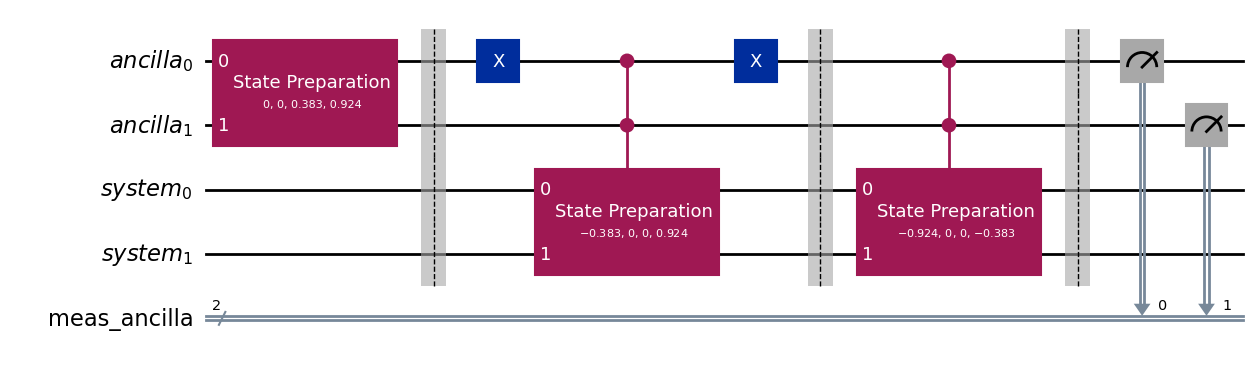

In [4]:
# Display the circuit architecture natively in the notebook
final_circuit.draw(output='mpl')

### 3.4 Understanding the Test Case Output

In this demonstration, we input a 50/50 mix of the pure state $|00\rangle$ and the Bell state $|\Phi^+\rangle$. Because these two states share a probability overlap at $|00\rangle$ and are not orthogonal, the spectral decomposition algorithm must find a new, perfectly distinguishable basis.

**The Mathematical Shift:**
* **Input:** A non-orthogonal mixture (50% $|00\rangle$ and 50% $|\Phi^+\rangle$).
* **Eigenvalues (New Probabilities):** Constructive interference at $|00\rangle$ shifts the classical probabilities to $\approx 85.3\%$ and $\approx 14.7\%$.
* **Ancilla Amplitudes:** The square root of these probabilities yields the precise ancilla initialization values ($\approx 0.9238$ and $\approx 0.3826$).

**Circuit Execution:**
The circuit maps these exact amplitudes onto the ancilla register. The multiplexed entangling block then isolates each specific ancilla state ($|00\rangle_A$ and $|01\rangle_A$) using Pauli-X gates to conditionally prepare the corresponding orthogonal eigenvectors on the main system register. Finally, measuring and discarding the ancilla executes the partial trace, forcing the system to collapse into the exact target mixed state.

## 4. Conclusion and Advanced Extensions

This implementation successfully provides a generalized method for preparing arbitrary mixed quantum states via state purification. By intentionally losing information to an ancilla register, we have developed a tool to interface pristine quantum hardware with messy, realistic physical environments.

**Scalability and Future Research:**
While this spectral decomposition approach is mathematically exact, scaling to larger $n$-qubit systems requires significant computational overhead. To address this in advanced physical simulations, we must frequently explore alternative state preparation algorithms using tensor networks or exact diagonalization techniques. 

These methods are highly relevant when mapping complex theoretical models onto quantum hardware. For example, preparing accurate thermal states is a strict prerequisite for simulating the dynamics of a Bose-Einstein Condensate or studying temperature-dependent topological phases. Optimized quantum interferometry offers a compelling path for extending this generalized function into highly specialized condensed matter applications.